# Pandas GroupBy Notes

**Source:** `exercise.ipynb`  
**Goal:** practice a few small but useful pandas patterns: grouped summaries, mixed-type column inspection, and quick feature creation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.precision", 3)

print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")

numpy 2.0.0
pandas 2.2.2


## Grouped summaries

I started with a tiny table so I could inspect each step and make sure the aggregation logic was easy to follow.

In [2]:
df = pd.DataFrame({
    "team": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
    "round": ["one", "one", "two", "three", "two", "two", "one", "three"],
    "score_a": np.random.randn(8),
    "score_b": np.random.randn(8),
})

df

,team,round,score_a,score_b
0,foo,one,0.497,-0.469
1,bar,one,-0.138,0.543
2,foo,two,0.648,-0.463
3,bar,three,1.523,-0.466
4,foo,two,-0.234,0.242
5,bar,two,-0.234,-1.913
6,foo,one,1.579,-1.725
7,foo,three,0.767,-0.562


In [3]:
grouped = df.groupby("team")[["score_a", "score_b"]].agg(["mean", "sum", "max"])
grouped

score_a               score_b              
        mean    sum    max    mean    sum    max
team                                            
bar    0.384  1.151  1.523  -0.612 -1.836  0.543
foo    0.651  3.257  1.579  -0.596 -2.978  0.242

,score_a,score_b
team,,
bar,1.151,-1.836
foo,3.257,-2.978


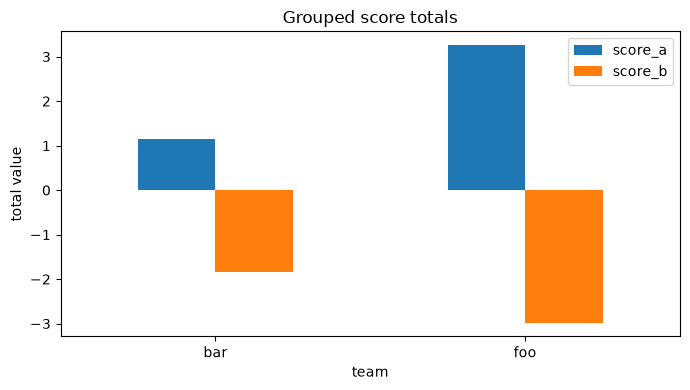

In [4]:
team_totals = df.groupby("team")[["score_a", "score_b"]].sum()
ax = team_totals.plot(kind="bar", figsize=(7, 4), title="Grouped score totals")
ax.set_ylabel("total value")
plt.xticks(rotation=0)
plt.tight_layout()
team_totals

## Finding columns that are not fully numeric

The original scratch notebook experimented with mixed values. A clean way to inspect that is to coerce each column to numeric and check whether any values turn into missing data.

In [5]:
mixed_df = pd.DataFrame({
    "A": [1, 2, 3, "a", "b", "c"],
    "B": [4, 5, 6, 7, 8, 9],
    "C": [1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
})

coerced = mixed_df.apply(pd.to_numeric, errors="coerce")
non_numeric_columns = coerced.columns[coerced.isna().any()].tolist()

print("Columns with non-numeric values:", non_numeric_columns)
pd.concat({"original": mixed_df, "coerced": coerced}, axis=1)

Columns with non-numeric values: ['A']


original         coerced        
         A  B    C       A  B    C
0        1  4  1.5     1.0  4  1.5
1        2  5  2.5     2.0  5  2.5
2        3  6  3.5     3.0  6  3.5
3        a  7  4.5     NaN  7  4.5
4        b  8  5.5     NaN  8  5.5
5        c  9  6.5     NaN  9  6.5

## Simple feature creation

A lot of pandas work comes down to building small derived columns that make later analysis easier.

In [6]:
scores = pd.DataFrame({
    "a": [1, 2, 3],
    "b": [4, 5, 6],
    "c": [7, 8, 9],
})

scores["total"] = scores[["a", "b", "c"]].sum(axis=1)
scores["mean_score"] = scores[["a", "b", "c"]].mean(axis=1)
scores

,a,b,c,total,mean_score
0,1,4,7,12,4.0
1,2,5,8,15,5.0
2,3,6,9,18,6.0


## What I learned

- `groupby` becomes much easier to reason about when the sample table is small and reproducible.
- `pd.to_numeric(..., errors="coerce")` is a quick way to spot columns that hide string values.
- Creating derived columns early often makes the next analysis step much cleaner.